# Representing Images as Vectors and Computing Angles and Distances

## 📚 Learning Objectives

By completing this notebook, you will:
- Represent images as vectors
- Compute angles and distances between image vectors
- Understand inner product and distance measures
- Apply similarity measures to compare images

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 05 "CNN for Image Classification" — you fed images to a network there; here we treat an image as a plain vector and measure distance directly.

**Used later in:** Course 07 (AIAT 121) — Unit 2, lesson 02 "Word Embeddings" — cosine similarity between vectors, the same measure applied to words.

---

This notebook covers practical activities from **Course 03, Unit 3**:
- Representing images as vectors and computing angles and distances between them

---

## Introduction

**Images can be represented as high-dimensional vectors** by flattening pixel values. We can then compute angles, distances, and similarity measures between images using linear algebra concepts.


---

## 📌 Real case: five different pictures with exactly the same error

In 2004 Zhou Wang, Alan Bovik, Hamid Sheikh and Eero Simoncelli published
*"Image Quality Assessment: From Error Visibility to Structural Similarity"* (IEEE Transactions on Image
Processing 13(4)) and opened it with a figure that has been reproduced ever since. They take one
photograph of a boat and produce five distorted versions — contrast-stretched, mean-shifted,
JPEG-compressed, blurred, and contaminated with salt-and-pepper noise — each adjusted so that all five have
**exactly the same MSE of 210** relative to the original. To a human eye they are not remotely equally
damaged: the mean-shifted image looks almost perfect, the JPEG one is visibly wrecked. Their SSIM index
scores them 0.9900 and 0.6949 respectively.

MSE — the squared Euclidean distance this notebook computes between flattened images — cannot tell those
five apart. It measures *pixel disagreement*, and human perception measures *structure*.

**What goes wrong without this.** Rank a photo library by Euclidean distance and you will retrieve images
that share a brightness level, not images that share a subject. Optimise an image model with MSE and it
will learn to produce the blurry average of every plausible answer, because blurring is the safest way to
keep squared error low. That is not a hypothetical: it is why generative image models moved to perceptual
and adversarial losses.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib, sklearn's digit images, and SciPy's ready-made distance functions.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from scipy.spatial.distance import cosine, euclidean

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nRepresenting Images as Vectors and Computing Angles and Distances")
print("=" * 60)

✅ Libraries imported!

Representing Images as Vectors and Computing Angles and Distances


## Part 1: Representing Images as Vectors


Part 1: Representing Images as Vectors

Loaded 1797 images
Image shape: (8, 8)
Image dimension (flattened): (64,)

Vector representation shape: (1797, 64)
Each image is now a 64-dimensional vector


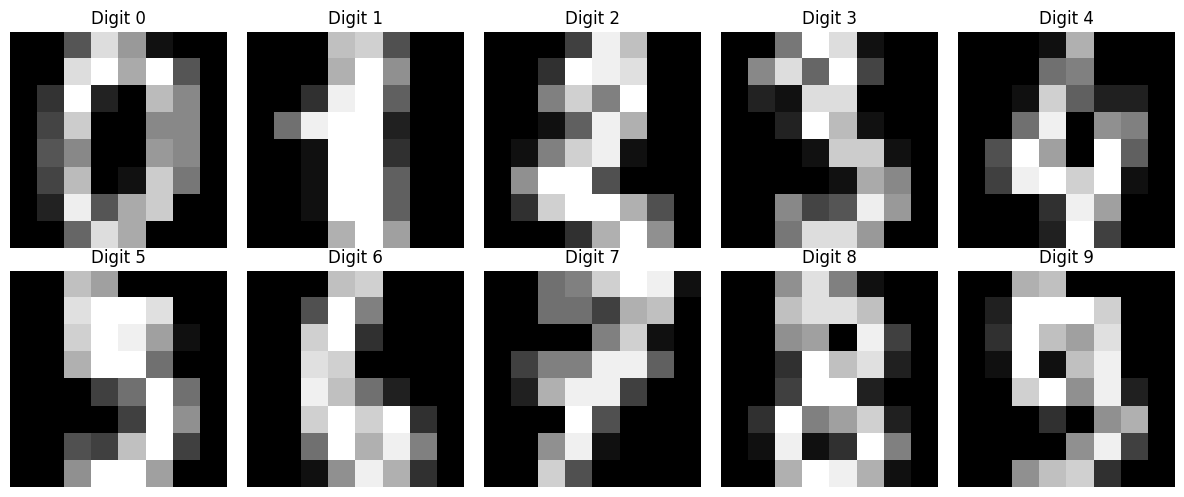


✅ Images represented as vectors!


In [2]:
# Turn 8x8 digit images into 64-dimensional vectors — flattening is the bridge that lets
# plain linear algebra (distances, angles) operate on pictures.

print("=" * 60)
print("Part 1: Representing Images as Vectors")
print("=" * 60)

# Load digit images (8x8 pixels each)
digits = load_digits()
images = digits.images
labels = digits.target

print(f"\nLoaded {len(images)} images")
print(f"Image shape: {images[0].shape}")
print(f"Image dimension (flattened): {images[0].flatten().shape}")

# Flatten images to vectors
image_vectors = images.reshape(len(images), -1)
print(f"\nVector representation shape: {image_vectors.shape}")
print(f"Each image is now a {image_vectors.shape[1]}-dimensional vector")

# Visualize some images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Digit {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

print("\n✅ Images represented as vectors!")

### 📊 What to see in the figure above

Ten digits, one per class, drawn at their true resolution: **8 × 8 = 64 grey squares**, and
nothing more. There is no smoothing and no detail — the `8` and the `9` differ by a handful
of pixels, and you can count every pixel that separates them. That coarseness is the point:
each of these pictures is now a list of 64 numbers, which is why the rest of the notebook
can measure "how similar are two images?" with nothing but arithmetic on vectors.

## Part 2: Computing Angles and Distances Between Images



Part 2: Computing Angles and Distances Between Images

Comparing images:
  Image 1: Digit 0
  Image 2: Digit 1
  Image 3: Digit 4

Comparison Results:

Image 1 vs Image 2 (Digits 0 vs 1):
  Euclidean distance: 59.5567
  Cosine similarity: 0.5191
  Angle: 58.73° (1.0250 radians)

Image 1 vs Image 3 (Digits 0 vs 4):
  Euclidean distance: 50.4282
  Cosine similarity: 0.6047
  Angle: 52.80° (0.9214 radians)


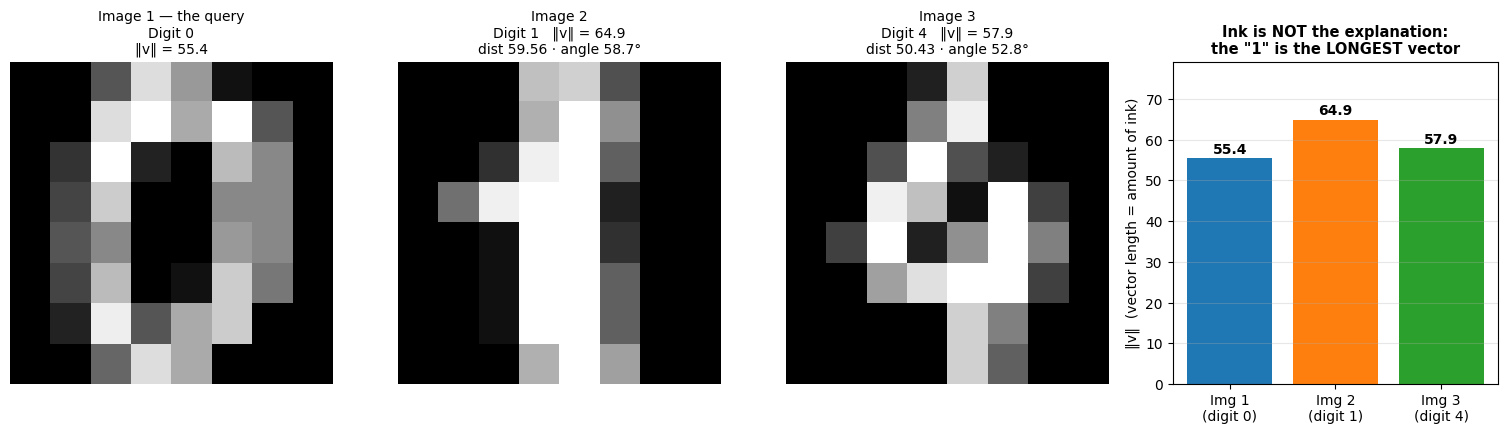


Vector lengths: image 1 = 55.41, image 2 = 64.88, image 3 = 57.91
The 0 is closer to the 4 (50.43) than to the 1 (59.56) — and the 1 is
the LONGEST vector of the three, so 'the 1 has less ink' cannot be the reason.
The angles say the same thing: 52.8° to the 4 versus 58.7° to the 1.
Here the two measures agree. The next cell builds a case where they do NOT.

✅ Angles and distances computed!


In [3]:
# Measure how alike two images are with Euclidean distance and cosine similarity (the angle between vectors).
# These two metrics power nearest-neighbor search, embeddings, and recommender systems.

print("\n" + "=" * 60)
print("Part 2: Computing Angles and Distances Between Images")
print("=" * 60)

# Select a few images for comparison
img1_idx = 0
img2_idx = 1
img3_idx = 100

img1_vec = image_vectors[img1_idx]
img2_vec = image_vectors[img2_idx]
img3_vec = image_vectors[img3_idx]

print(f"\nComparing images:")
print(f"  Image 1: Digit {labels[img1_idx]}")
print(f"  Image 2: Digit {labels[img2_idx]}")
print(f"  Image 3: Digit {labels[img3_idx]}")

# Euclidean distance (L2 norm)
def euclidean_distance(v1, v2):
    """Compute Euclidean distance between two vectors"""
    return np.linalg.norm(v1 - v2)

# Cosine similarity (inner product of normalized vectors)
def cosine_similarity(v1, v2):
    """Compute cosine similarity between two vectors"""
    dot_product = np.dot(v1, v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    if norm1 == 0 or norm2 == 0:
        return 0
    return dot_product / (norm1 * norm2)

# Angle between vectors (in radians and degrees)
def angle_between_vectors(v1, v2):
    """Compute angle between two vectors"""
    cos_sim = cosine_similarity(v1, v2)
    # Clamp to avoid numerical errors
    cos_sim = np.clip(cos_sim, -1.0, 1.0)
    angle_rad = np.arccos(cos_sim)
    angle_deg = np.degrees(angle_rad)
    return angle_rad, angle_deg

# Compute distances and angles
dist_12 = euclidean_distance(img1_vec, img2_vec)
dist_13 = euclidean_distance(img1_vec, img3_vec)
sim_12 = cosine_similarity(img1_vec, img2_vec)
sim_13 = cosine_similarity(img1_vec, img3_vec)
angle_12_rad, angle_12_deg = angle_between_vectors(img1_vec, img2_vec)
angle_13_rad, angle_13_deg = angle_between_vectors(img1_vec, img3_vec)

print("\n" + "=" * 60)
print("Comparison Results:")
print("=" * 60)
print(f"\nImage 1 vs Image 2 (Digits {labels[img1_idx]} vs {labels[img2_idx]}):")
print(f"  Euclidean distance: {dist_12:.4f}")
print(f"  Cosine similarity: {sim_12:.4f}")
print(f"  Angle: {angle_12_deg:.2f}° ({angle_12_rad:.4f} radians)")

print(f"\nImage 1 vs Image 3 (Digits {labels[img1_idx]} vs {labels[img3_idx]}):")
print(f"  Euclidean distance: {dist_13:.4f}")
print(f"  Cosine similarity: {sim_13:.4f}")
print(f"  Angle: {angle_13_deg:.2f}° ({angle_13_rad:.4f} radians)")

# Visualize comparisons
# Three thumbnails plus the quantity the numbers actually depend on: each image's vector
# LENGTH ||v||, i.e. how much ink is on the page. Printing the length next to the distance
# is what lets a student check whether "more ink" or "different shape" is doing the work.
norm1 = np.linalg.norm(img1_vec)
norm2 = np.linalg.norm(img2_vec)
norm3 = np.linalg.norm(img3_vec)

fig, axes = plt.subplots(1, 4, figsize=(15.2, 4.3))
axes[0].imshow(images[img1_idx], cmap='gray')
axes[0].set_title(f'Image 1 — the query\nDigit {labels[img1_idx]}\n‖v‖ = {norm1:.1f}', fontsize=10)
axes[0].axis('off')
axes[1].imshow(images[img2_idx], cmap='gray')
axes[1].set_title(f'Image 2\nDigit {labels[img2_idx]}   ‖v‖ = {norm2:.1f}\n'
                  f'dist {dist_12:.2f} · angle {angle_12_deg:.1f}°', fontsize=10)
axes[1].axis('off')
axes[2].imshow(images[img3_idx], cmap='gray')
axes[2].set_title(f'Image 3\nDigit {labels[img3_idx]}   ‖v‖ = {norm3:.1f}\n'
                  f'dist {dist_13:.2f} · angle {angle_13_deg:.1f}°', fontsize=10)
axes[2].axis('off')

# Panel 4: the three vector lengths side by side. WHY this panel exists: the tempting
# explanation for "the 0 is closer to the 4 than to the 1" is "the 1 has less ink". These
# bars let you reject that explanation instead of repeating it.
labs = [f'Img 1\n(digit {labels[img1_idx]})', f'Img 2\n(digit {labels[img2_idx]})',
        f'Img 3\n(digit {labels[img3_idx]})']
vals = [norm1, norm2, norm3]
bars = axes[3].bar(labs, vals, color=['tab:blue', 'tab:orange', 'tab:green'])
for b, v in zip(bars, vals):
    axes[3].text(b.get_x() + b.get_width() / 2, v + 1.2, f'{v:.1f}', ha='center',
                 fontsize=10, fontweight='bold')
axes[3].set_ylabel('‖v‖  (vector length = amount of ink)', fontsize=10)
axes[3].set_ylim(0, max(vals) * 1.22)
axes[3].set_title('Ink is NOT the explanation:\nthe "1" is the LONGEST vector', fontsize=10.5,
                  fontweight='bold')
axes[3].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nVector lengths: image 1 = {norm1:.2f}, image 2 = {norm2:.2f}, image 3 = {norm3:.2f}")
print(f"The 0 is closer to the 4 ({dist_13:.2f}) than to the 1 ({dist_12:.2f}) — and the 1 is")
print(f"the LONGEST vector of the three, so 'the 1 has less ink' cannot be the reason.")
print(f"The angles say the same thing: {angle_13_deg:.1f}° to the 4 versus "
      f"{angle_12_deg:.1f}° to the 1.")
print("Here the two measures agree. The next cell builds a case where they do NOT.")

print("\n✅ Angles and distances computed!")

### 📊 What to see in the figure above

The three thumbnails now carry **‖v‖**, the length of each image's 64-dimensional vector —
which is simply how much ink is on that 8×8 grid. Read the surprise first: the query **0**
is closer to the **4** (distance 50.43, angle 52.8°) than to the **1** (distance 59.56,
angle 58.7°). A `0` and a `4` are not alike to a human eye.

Then use the fourth panel to reject the easy explanation. The tempting story is "the 1 is a
thin stroke, so it has little ink, so its vector is short, so it sits far from everything."
The bars say otherwise: **the 1 is the LONGEST vector of the three at ‖v‖ = 64.9**, against
55.4 for the 0 and 57.9 for the 4. Ink is not what separated them here — *where* the ink
sits is, and a `4` happens to darken more of the same pixels a `0` darkens than a
centre-column `1` does. Both measures agree on this trio; the next cell constructs a case
where they flatly disagree.

### 🧪 The controlled experiment: change ONE thing — the brightness

The three images above differ in shape *and* in ink, so they cannot separate the two
effects. So change one thing only. Take the query image and make an identical copy at
**half brightness** — every pixel multiplied by 0.5. Same digit, same handwriting, same
stroke positions; only the intensity is different. Then ask each measure how similar the
copy is to the original.

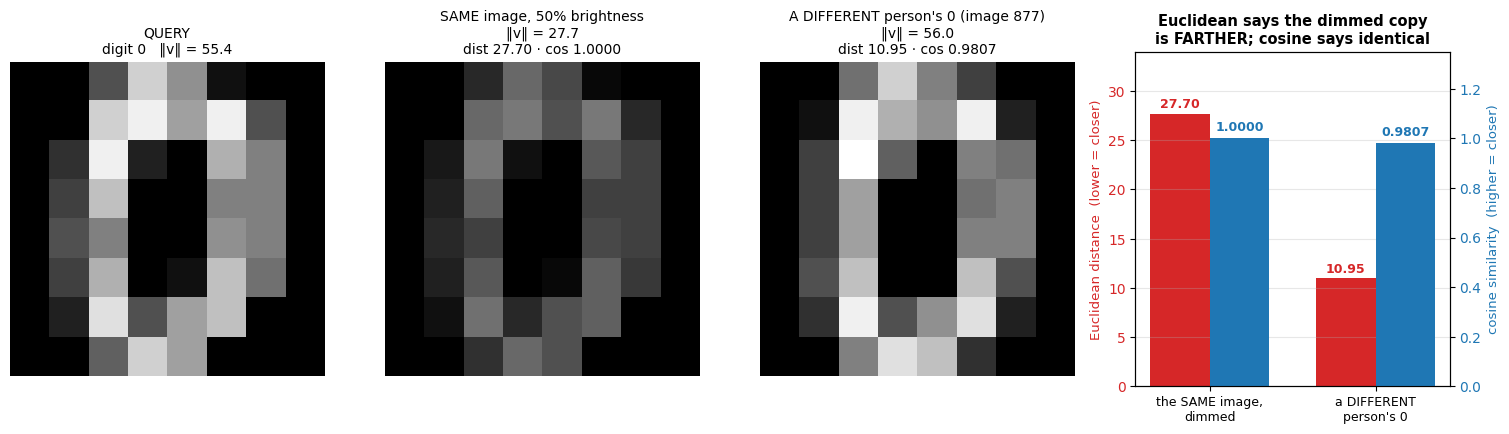

Same picture, half the brightness:
  Euclidean distance : 27.70   (0 would mean identical)
  Cosine similarity  : 1.000000   (1 means identical direction)

A genuinely different handwritten 0 (image 877):
  Euclidean distance : 10.95  — CLOSER than the image's own dimmed copy
  Cosine similarity  : 0.980739

140 of the 1797 images in this dataset are Euclidean-closer to the
query than the query's OWN dimmed copy — and 140 of those 140 are also 0s.

So: turn the lamp down and Euclidean distance calls a picture a stranger, while
cosine similarity scores it a perfect 1.0. Use cosine when the overall level is an
accident of capture (scanner brightness, document length, audio gain). Use Euclidean
when the level is part of what you are measuring.


In [4]:
# Controlled experiment: the SAME image at 50% brightness, against a genuinely different
# photograph of the same digit. WHY: this is the only way to see what each measure is
# actually sensitive to — everything except brightness is held fixed.

bright_query = image_vectors[0].astype(float)          # the query zero
bright_dimmed = 0.5 * bright_query                     # identical shape, half the ink
# The closest OTHER real image to the query, by Euclidean distance — a different person's
# handwriting, found by search rather than hand-picked.
bright_d_all = np.linalg.norm(image_vectors - bright_query, axis=1)
bright_order = np.argsort(bright_d_all)
bright_real_idx = int(bright_order[1])                 # [0] is the query itself

bright_d_dim = float(np.linalg.norm(bright_query - bright_dimmed))
bright_d_real = float(bright_d_all[bright_real_idx])
bright_c_dim = cosine_similarity(bright_query, bright_dimmed)
bright_c_real = cosine_similarity(bright_query, image_vectors[bright_real_idx])
# How many genuinely different images the dimmed copy is beaten by, on Euclidean distance.
bright_closer = int((bright_d_all < bright_d_dim).sum()) - 1        # minus the query itself
bright_closer_zeros = int(((bright_d_all < bright_d_dim) & (labels == labels[0])).sum()) - 1

fig, axes = plt.subplots(1, 4, figsize=(15.2, 4.4))
axes[0].imshow(bright_query.reshape(8, 8), cmap='gray', vmin=0, vmax=16)
axes[0].set_title(f'QUERY\ndigit {labels[0]}   ‖v‖ = {np.linalg.norm(bright_query):.1f}',
                  fontsize=10)
axes[0].axis('off')
axes[1].imshow(bright_dimmed.reshape(8, 8), cmap='gray', vmin=0, vmax=16)
axes[1].set_title(f'SAME image, 50% brightness\n‖v‖ = {np.linalg.norm(bright_dimmed):.1f}\n'
                  f'dist {bright_d_dim:.2f} · cos {bright_c_dim:.4f}', fontsize=10)
axes[1].axis('off')
axes[2].imshow(images[bright_real_idx], cmap='gray', vmin=0, vmax=16)
axes[2].set_title(f'A DIFFERENT person\'s {labels[bright_real_idx]} (image {bright_real_idx})\n'
                  f'‖v‖ = {np.linalg.norm(image_vectors[bright_real_idx]):.1f}\n'
                  f'dist {bright_d_real:.2f} · cos {bright_c_real:.4f}', fontsize=10)
axes[2].axis('off')

# Panel 4: the two measures disagree, and the bars say by how much.
x = np.arange(2)
w = 0.36
ax4 = axes[3]
b1 = ax4.bar(x - w / 2, [bright_d_dim, bright_d_real], w, color='tab:red')
# The direction of "better" goes in the AXIS LABEL, not in a legend: two legend boxes on
# a twin-axis panel this narrow overlap each other and both become unreadable.
ax4.set_ylabel('Euclidean distance  (lower = closer)', color='tab:red', fontsize=9.5)
ax4.tick_params(axis='y', labelcolor='tab:red')
ax4.set_ylim(0, 34)
ax4r = ax4.twinx()
b2 = ax4r.bar(x + w / 2, [bright_c_dim, bright_c_real], w, color='tab:blue')
ax4r.set_ylabel('cosine similarity  (higher = closer)', color='tab:blue', fontsize=9.5)
ax4r.tick_params(axis='y', labelcolor='tab:blue')
ax4r.set_ylim(0, 1.35)
for b, v in zip(b1, [bright_d_dim, bright_d_real]):
    ax4.text(b.get_x() + b.get_width() / 2, v + 0.6, f'{v:.2f}', ha='center', fontsize=9,
             color='tab:red', fontweight='bold')
for b, v in zip(b2, [bright_c_dim, bright_c_real]):
    ax4r.text(b.get_x() + b.get_width() / 2, v + 0.03, f'{v:.4f}', ha='center', fontsize=9,
              color='tab:blue', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(['the SAME image,\ndimmed', f'a DIFFERENT\nperson\'s {labels[bright_real_idx]}'],
                    fontsize=9)
ax4.set_title('Euclidean says the dimmed copy\nis FARTHER; cosine says identical',
              fontsize=10.5, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("=" * 74)
print("Same picture, half the brightness:")
print(f"  Euclidean distance : {bright_d_dim:.2f}   (0 would mean identical)")
print(f"  Cosine similarity  : {bright_c_dim:.6f}   (1 means identical direction)")
print(f"\nA genuinely different handwritten {labels[bright_real_idx]} (image {bright_real_idx}):")
print(f"  Euclidean distance : {bright_d_real:.2f}  — CLOSER than the image's own dimmed copy")
print(f"  Cosine similarity  : {bright_c_real:.6f}")
print(f"\n{bright_closer} of the {len(image_vectors)} images in this dataset are Euclidean-closer to the")
print(f"query than the query's OWN dimmed copy — and {bright_closer_zeros} of those "
      f"{bright_closer} are also {labels[0]}s.")
print("\nSo: turn the lamp down and Euclidean distance calls a picture a stranger, while")
print("cosine similarity scores it a perfect 1.0. Use cosine when the overall level is an")
print("accident of capture (scanner brightness, document length, audio gain). Use Euclidean")
print("when the level is part of what you are measuring.")

### 📊 What to see in the figure above

**Compare the first two thumbnails.** They are the same handwriting, the same strokes, the
same pixels — the middle one is simply half as bright, and you can see that it is greyer.
Now read the two numbers under it: **Euclidean distance 27.70** (0 would mean identical)
and **cosine similarity 1.0000** (1 means identical direction). One measure calls the
image a stranger; the other says it is the very same thing. Both are right about what they
measure — length changed, direction did not.

**The third thumbnail is the reality check.** Image 877 is a `0` written by a different
person: visibly not the same handwriting. Its Euclidean distance to the query is **10.95 —
less than half the distance to the query's own dimmed copy.** The right-hand bars put the
two comparisons side by side: the red Euclidean bar is much taller for the *dimmed copy of
itself* than for a *genuinely different image*, while the blue cosine bars are nearly
level (1.0000 vs 0.9807).

**And it is not one lucky example.** The printed line says **140 of the 1,797 images are
Euclidean-closer to the query than its own dimmed copy** — every one of them a different
handwritten `0`. Turn the lamp down and Euclidean-distance search loses the picture
entirely. That is the rule to take away: use cosine when the overall level is an accident
of capture — scanner brightness, document length, microphone gain — and use Euclidean when
the level is part of what you actually mean by "different".

## Part 3: Finding Similar Images

**Nearest-neighbor search**: compare a query image (a handwritten 0) against all 1,797 digit vectors and rank them.

Two rankings are shown:
- **By Euclidean distance** (smaller = more similar) — sensitive to overall brightness and stroke intensity.
- **By cosine similarity** (larger = more similar) — compares only the *direction* of the pixel vectors, ignoring overall intensity.

Both rankings retrieve other handwritten 0s as the closest matches — pixel-space geometry alone is enough to group digits — though the two measures need not agree on the exact order.



Part 3: Finding Similar Images

Query image: Digit 0

Top 5 most similar images (by Euclidean distance):
  1. Image 0 (Digit 0) - Distance: 0.0000 [QUERY]
  2. Image 877 (Digit 0) - Distance: 10.9545
  3. Image 1365 (Digit 0) - Distance: 12.8062
  4. Image 1541 (Digit 0) - Distance: 13.1149
  5. Image 1167 (Digit 0) - Distance: 13.2665
  6. Image 1029 (Digit 0) - Distance: 13.3417

Top 5 most similar images (by cosine similarity):
  1. Image 0 (Digit 0) - Similarity: 1.0000 [QUERY]
  2. Image 877 (Digit 0) - Similarity: 0.9807
  3. Image 464 (Digit 0) - Similarity: 0.9745
  4. Image 1365 (Digit 0) - Similarity: 0.9742
  5. Image 1541 (Digit 0) - Similarity: 0.9718
  6. Image 1167 (Digit 0) - Similarity: 0.9711


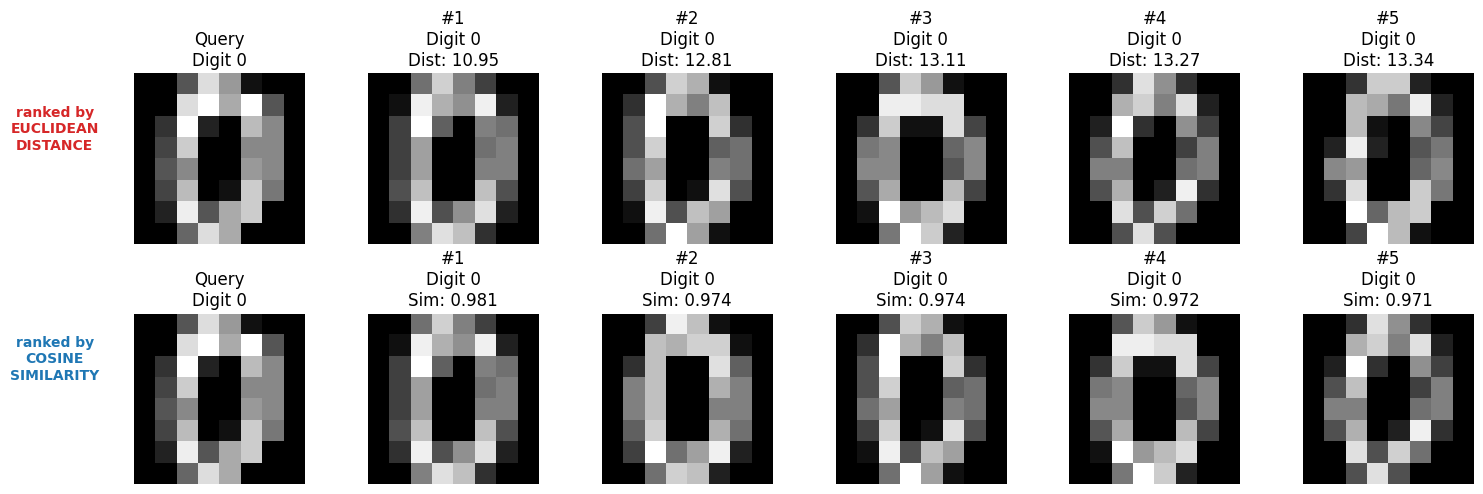


✅ Similar images found!


In [5]:
# Mini image search engine: rank every digit image by its distance/similarity to a query image.
# Nearest-neighbor retrieval like this is the primitive behind reverse image search.

print("\n" + "=" * 60)
print("Part 3: Finding Similar Images")
print("=" * 60)

# Find most similar images to a query image
query_idx = 0
query_vec = image_vectors[query_idx]
query_label = labels[query_idx]

print(f"\nQuery image: Digit {query_label}")

# Compute distances to all images
distances = []
similarities = []
for i in range(len(image_vectors)):
    dist = euclidean_distance(query_vec, image_vectors[i])
    sim = cosine_similarity(query_vec, image_vectors[i])
    distances.append((i, dist, labels[i]))
    similarities.append((i, sim, labels[i]))

# Sort by distance (ascending) and similarity (descending)
distances_sorted = sorted(distances, key=lambda x: x[1])
similarities_sorted = sorted(similarities, key=lambda x: x[1], reverse=True)

# Get top 5 most similar
print("\nTop 5 most similar images (by Euclidean distance):")
for i, (idx, dist, label) in enumerate(distances_sorted[:6]):  # Skip first (itself)
    if i == 0:
        print(f"  {i+1}. Image {idx} (Digit {label}) - Distance: {dist:.4f} [QUERY]")
    else:
        print(f"  {i+1}. Image {idx} (Digit {label}) - Distance: {dist:.4f}")

print("\nTop 5 most similar images (by cosine similarity):")
for i, (idx, sim, label) in enumerate(similarities_sorted[:6]):  # Skip first (itself)
    if i == 0:
        print(f"  {i+1}. Image {idx} (Digit {label}) - Similarity: {sim:.4f} [QUERY]")
    else:
        print(f"  {i+1}. Image {idx} (Digit {label}) - Similarity: {sim:.4f}")

# Visualize query and similar images
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    if i == 0:
        idx = query_idx
        title = f'Query\nDigit {labels[idx]}'
    else:
        idx = distances_sorted[i][0]
        dist = distances_sorted[i][1]
        title = f'#{i}\nDigit {labels[idx]}\nDist: {dist:.2f}'
    
    axes[0, i].imshow(images[idx], cmap='gray')
    axes[0, i].set_title(title)
    axes[0, i].axis('off')

for i in range(6):
    if i == 0:
        idx = query_idx
        title = f'Query\nDigit {labels[idx]}'
    else:
        idx = similarities_sorted[i][0]
        sim = similarities_sorted[i][1]
        title = f'#{i}\nDigit {labels[idx]}\nSim: {sim:.3f}'
    
    axes[1, i].imshow(images[idx], cmap='gray')
    axes[1, i].set_title(title)
    axes[1, i].axis('off')

# set_ylabel does nothing on an axis with axis('off') - the two row labels were being
# created and never drawn. Figure-level text is what actually appears.
plt.tight_layout(rect=[0.055, 0, 1, 1])
fig.text(0.028, 0.74, 'ranked by\nEUCLIDEAN\nDISTANCE', ha='center', va='center',
         fontsize=10, fontweight='bold', rotation=0, color='tab:red')
fig.text(0.028, 0.28, 'ranked by\nCOSINE\nSIMILARITY', ha='center', va='center',
         fontsize=10, fontweight='bold', rotation=0, color='tab:blue')
plt.show()

print("\n✅ Similar images found!")

### 📊 What to see in the figure above

Both rows start from the same query on the left, and **both rows return ten zeros** — no
other digit appears. That alone is the headline: raw pixel geometry, with no training and
no notion of what a digit *is*, is enough to group handwriting by class in this dataset.

Now compare the two rows position by position. `#1` is image 877 in both. But `#2`
differs: the Euclidean row's second-best is at distance 12.81, while the cosine row's
second-best is image 464 — which does **not** appear anywhere in the Euclidean top five.
The two measures agree on the neighbourhood and disagree on the order inside it, exactly as
the brightness experiment predicted: image 464 points in nearly the same direction as the
query but carries a different amount of ink, so cosine promotes it and Euclidean demotes it.

---

## ⚠️ Where this breaks

- **Euclidean distance measures brightness as much as shape.** The controlled experiment in Part 2 makes
  it unarguable: the query image at **50% brightness** — same handwriting, same strokes — sits at Euclidean
  distance **27.70** from the original, while **140 genuinely different people's zeros are closer than
  that**, the nearest at 10.95. Cosine similarity scores the dimmed copy **1.000000**, because it compares
  direction only and dimming does not change direction. Note what this bullet does *not* claim: raw
  pixel distance is not simply "how much ink". Part 2's first figure shows the `1` is the **longest**
  vector of the three (‖v‖ = 64.9 against 55.4 and 57.9), yet it is the farthest from the `0` — *where*
  the ink sits matters as much as how much of it there is. Both effects are in play, which is why the two
  rankings in Part 3 are not identical (image 464 makes the cosine top-5 and not the Euclidean one).
- **Neither measure knows what a digit is.** These vectors have no notion of translation, rotation or
  stroke thickness. Shift a well-written 8 by one pixel and its distance to the original 8 can exceed its
  distance to a completely different digit. That is why convolutional networks — which build in translation
  tolerance — replaced raw-pixel nearest neighbours for images, and why the 8/9, 7/9 and 1/8 confusions
  that appear elsewhere in this course are not accidents.
- **8×8 is the reason this works at all.** These images are 64-dimensional. Real photographs are millions
  of dimensions, where every pair of points is roughly equidistant (Unit 4, notebook 02) and raw-pixel
  nearest-neighbour search stops meaning anything. The condition that must hold: either low dimension, or
  an embedding learned for the task. Cheaper alternative before reaching for deep features: reduce
  dimension first (PCA, Unit 4) and search in that space.


---

## 💬 Discuss

1. Wang and colleagues built five images with identical MSE and obviously different quality. If your
   metric cannot distinguish cases a human distinguishes instantly, is the metric wrong or is the human
   irrelevant? Take a position and defend it with a use case.
2. The query in Part 3 retrieved other zeros under both measures, but in a different order. When would
   that difference in order actually matter to someone — and how would you decide which order is right?
3. A Saudi bank wants to catch duplicate submissions of scanned ID documents. Would you use Euclidean
   distance, cosine similarity, or neither? Justify your choice by naming the specific way each one could
   be fooled.


## Summary

### Key Concepts:
1. **Image Representation**: Images can be flattened into vectors
2. **Euclidean Distance**: L2 norm, measures absolute difference
3. **Cosine Similarity**: Normalized dot product, measures angle
4. **Angle Between Vectors**: Computed from cosine similarity
5. **Similarity Search**: Find similar images using distance/similarity measures

### Best Practices:
- Normalize vectors for cosine similarity
- Use Euclidean distance for magnitude differences
- Use cosine similarity for direction/orientation differences
- Consider dimensionality when computing distances

### Applications:
- Image retrieval
- Face recognition
- Content-based image search
- Clustering similar images

**Reference:** Course 03, Unit 3: "Optimization and Statistical Foundations" - Image similarity measures practical content

---

## 🔭 State of the field (2026)

Nobody compares raw pixel vectors in 2026. An image is first passed through a pretrained encoder — CLIP
(Radford et al. 2021), and in the current open generation vision-language models such as Qwen3-VL (Bai et al.
2025) — and the distance is taken between the resulting **embeddings**, so two photographs of the same object
land close together even when no pixel agrees. Reverse image search, duplicate detection and multimodal
retrieval all work this way, and the text side is identical (Zhang et al. 2025).

**Why this lesson is still the right thing to learn.** The geometry does not change when the vector changes.
An embedding is still a vector; similarity is still the cosine of the angle between two vectors; and the failure
you meet in Part 2 — a faintly drawn digit sitting far from everything because its vector is *short* — is
exactly why production systems normalize embeddings before comparing them. Learn the measures here on 64 pixels
you can see, then swap in a vector you cannot.

## 📚 References

1. Wang, Z., Bovik, A. C., Sheikh, H. R., & Simoncelli, E. P. (2004). *Image Quality Assessment: From Error Visibility to Structural Similarity*. IEEE Transactions on Image Processing, 13(4), 600–612. <https://doi.org/10.1109/TIP.2003.819861>
2. Radford, A., Kim, J. W., Hallacy, C., et al. (2021). *Learning Transferable Visual Models From Natural Language Supervision* (CLIP). ICML. <https://arxiv.org/abs/2103.00020>
3. Bai et al. (2025). *Qwen3-VL Technical Report*. arXiv. <https://arxiv.org/abs/2511.21631> — the current open vision-language models whose embedding spaces similarity is measured in today.
4. Zhang et al. (2025). *Qwen3 Embedding: Advancing Text Embedding and Reranking Through Foundation Models*. arXiv. <https://arxiv.org/abs/2506.05176> — the same idea for text: distances taken between learned vectors, not raw features.
